In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

In [2]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

import operator
from functools import reduce
from functools import partial

from timeit import default_timer
import scipy.io
from scipy.ndimage import gaussian_filter
import h5py
import sklearn.metrics
torch.manual_seed(0)
np.random.seed(0)

################################################################
# fourier layer
################################################################

In [4]:


#################################################
#
# Utilities
#
#################################################
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# reading data
class MatReader(object):
    def __init__(self, file_path, to_torch=True, to_cuda=False, to_float=True):
        super(MatReader, self).__init__()

        self.to_torch = to_torch
        self.to_cuda = to_cuda
        self.to_float = to_float

        self.file_path = file_path

        self.data = None
        self.old_mat = None
        self._load_file()

    def _load_file(self):
        try:
            self.data = scipy.io.loadmat(self.file_path)
            self.old_mat = True
        except:
            self.data = h5py.File(self.file_path)
            self.old_mat = False

    def load_file(self, file_path):
        self.file_path = file_path
        self._load_file()

    def read_field(self, field):
        x = self.data[field]

        if not self.old_mat:
            x = x[()]
            x = np.transpose(x, axes=range(len(x.shape) - 1, -1, -1))

        if self.to_float:
            x = x.astype(np.float32)

        if self.to_torch:
            x = torch.from_numpy(x)

            if self.to_cuda:
                x = x.cuda()

        return x

    def set_cuda(self, to_cuda):
        self.to_cuda = to_cuda

    def set_torch(self, to_torch):
        self.to_torch = to_torch

    def set_float(self, to_float):
        self.to_float = to_float

# normalization, pointwise gaussian
class UnitGaussianNormalizer(object):
    def __init__(self, x, eps=0.00001):
        super(UnitGaussianNormalizer, self).__init__()

        # x could be in shape of ntrain*n or ntrain*T*n or ntrain*n*T
        self.mean = torch.mean(x, 0)
        self.std = torch.std(x, 0)
        self.eps = eps

    def encode(self, x):
        x = (x - self.mean) / (self.std + self.eps)
        return x

    def decode(self, x, sample_idx=None):
        if sample_idx is None:
            std = self.std + self.eps # n
            mean = self.mean
        else:
            if len(self.mean.shape) == len(sample_idx[0].shape):
                std = self.std[sample_idx] + self.eps  # batch*n
                mean = self.mean[sample_idx]
            if len(self.mean.shape) > len(sample_idx[0].shape):
                std = self.std[:,sample_idx]+ self.eps # T*batch*n
                mean = self.mean[:,sample_idx]

        # x is in shape of batch*n or T*batch*n
        x = (x * std) + mean
        return x

    def cuda(self):
        self.mean = self.mean.cuda()
        self.std = self.std.cuda()

    def cpu(self):
        self.mean = self.mean.cpu()
        self.std = self.std.cpu()

# normalization, Gaussian
class GaussianNormalizer(object):
    def __init__(self, x, eps=0.00001):
        super(GaussianNormalizer, self).__init__()

        self.mean = torch.mean(x)
        self.std = torch.std(x)
        self.eps = eps

    def encode(self, x):
        x = (x - self.mean) / (self.std + self.eps)
        return x

    def decode(self, x, sample_idx=None):
        x = (x * (self.std + self.eps)) + self.mean
        return x

    def cuda(self):
        self.mean = self.mean.cuda()
        self.std = self.std.cuda()

    def cpu(self):
        self.mean = self.mean.cpu()
        self.std = self.std.cpu()


# normalization, scaling by range
class RangeNormalizer(object):
    def __init__(self, x, low=0.0, high=1.0):
        super(RangeNormalizer, self).__init__()
        mymin = torch.min(x, 0)[0].view(-1)
        mymax = torch.max(x, 0)[0].view(-1)

        self.a = (high - low)/(mymax - mymin)
        self.b = -self.a*mymax + high

    def encode(self, x):
        s = x.size()
        x = x.view(s[0], -1)
        x = self.a*x + self.b
        x = x.view(s)
        return x

    def decode(self, x):
        s = x.size()
        x = x.view(s[0], -1)
        x = (x - self.b)/self.a
        x = x.view(s)
        return x

#loss function with rel/abs Lp loss
class LpLoss(object):
    def __init__(self, d=2, p=2, size_average=True, reduction=True):
        super(LpLoss, self).__init__()

        #Dimension and Lp-norm type are postive
        assert d > 0 and p > 0

        self.d = d
        self.p = p
        self.reduction = reduction
        self.size_average = size_average

    def abs(self, x, y):
        num_examples = x.size()[0]

        #Assume uniform mesh
        h = 1.0 / (x.size()[1] - 1.0)

        all_norms = (h**(self.d/self.p))*torch.norm(x.view(num_examples,-1) - y.view(num_examples,-1), self.p, 1)

        if self.reduction:
            if self.size_average:
                return torch.mean(all_norms)
            else:
                return torch.sum(all_norms)

        return all_norms

    def rel(self, x, y):
        num_examples = x.size()[0]

        diff_norms = torch.norm(x.reshape(num_examples,-1) - y.reshape(num_examples,-1), self.p, 1)
        y_norms = torch.norm(y.reshape(num_examples,-1), self.p, 1)

        if self.reduction:
            if self.size_average:
                return torch.mean(diff_norms/y_norms)
            else:
                return torch.sum(diff_norms/y_norms)

        return diff_norms/y_norms

    def __call__(self, x, y):
        return self.rel(x, y)

# A simple feedforward neural network
class DenseNet(torch.nn.Module):
    def __init__(self, layers, nonlinearity, out_nonlinearity=None, normalize=False):
        super(DenseNet, self).__init__()

        self.n_layers = len(layers) - 1

        assert self.n_layers >= 1

        self.layers = nn.ModuleList()

        for j in range(self.n_layers):
            self.layers.append(nn.Linear(layers[j], layers[j+1]))

            if j != self.n_layers - 1:
                if normalize:
                    self.layers.append(nn.BatchNorm1d(layers[j+1]))

                self.layers.append(nonlinearity())

        if out_nonlinearity is not None:
            self.layers.append(out_nonlinearity())

    def forward(self, x):
        for _, l in enumerate(self.layers):
            x = l(x)

        return x

In [20]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt

import operator
from functools import reduce
from functools import partial

from timeit import default_timer
import scipy.io

torch.manual_seed(0)
np.random.seed(0)

################################################################
# fourier layer
################################################################

def compl_mul2d(a, b):
    op = partial(torch.einsum, "bctq,dctq->bdtq")
    return torch.stack([
        op(a[..., 0], b[..., 0]) - op(a[..., 1], b[..., 1]),
        op(a[..., 1], b[..., 0]) + op(a[..., 0], b[..., 1])
    ], dim=-1)


class SpectralConv2d_fast(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super(SpectralConv2d_fast, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1 #Number of Fourier modes to multiply, at most floor(N/2) + 1
        self.modes2 = modes2

        self.scale = (1 / (in_channels * out_channels))
        self.weights1 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, 2))
        self.weights2 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, 2))

    def forward(self, x):
        batchsize = x.shape[0]
        #Compute Fourier coeffcients up to factor of e^(- something constant)
        x_ft = torch.rfft(x, 2, normalized=True, onesided=True)

        # Multiply relevant Fourier modes
        out_ft = torch.zeros(batchsize, self.in_channels, x.size(-2), x.size(-1)//2 + 1, 2, device=x.device)
        out_ft[:, :, :self.modes1, :self.modes2] = \
            compl_mul2d(x_ft[:, :, :self.modes1, :self.modes2], self.weights1)
        out_ft[:, :, -self.modes1:, :self.modes2] = \
            compl_mul2d(x_ft[:, :, -self.modes1:, :self.modes2], self.weights2)

        #Return to physical space
        x = torch.irfft(out_ft, 2, normalized=True, onesided=True, signal_sizes=(x.size(-2), x.size(-1)))
        return x

class SimpleBlock2d(nn.Module):
    def __init__(self, modes1, modes2, width):
        super(SimpleBlock2d, self).__init__()

        self.modes1 = modes1
        self.modes2 = modes2
        self.width = width
        self.fc0 = nn.Linear(12, self.width)

        self.conv0 = SpectralConv2d_fast(self.width, self.width, self.modes1, self.modes2)
        self.conv1 = SpectralConv2d_fast(self.width, self.width, self.modes1, self.modes2)
        self.conv2 = SpectralConv2d_fast(self.width, self.width, self.modes1, self.modes2)
        self.conv3 = SpectralConv2d_fast(self.width, self.width, self.modes1, self.modes2)
        self.w0 = nn.Conv1d(self.width, self.width, 1)
        self.w1 = nn.Conv1d(self.width, self.width, 1)
        self.w2 = nn.Conv1d(self.width, self.width, 1)
        self.w3 = nn.Conv1d(self.width, self.width, 1)
        self.bn0 = torch.nn.BatchNorm2d(self.width)
        self.bn1 = torch.nn.BatchNorm2d(self.width)
        self.bn2 = torch.nn.BatchNorm2d(self.width)
        self.bn3 = torch.nn.BatchNorm2d(self.width)


        self.fc1 = nn.Linear(self.width, 128)
        self.fc2 = nn.Linear(128, 1)

    def forward(self, x):
        batchsize = x.shape[0]
        size_x, size_y = x.shape[1], x.shape[2]

        x = self.fc0(x)
        x = x.permute(0, 3, 1, 2)

        x1 = self.conv0(x)
        x2 = self.w0(x.view(batchsize, self.width, -1)).view(batchsize, self.width, size_x, size_y)
        x = self.bn0(x1 + x2)
        x = F.relu(x)
        x1 = self.conv1(x)
        x2 = self.w1(x.view(batchsize, self.width, -1)).view(batchsize, self.width, size_x, size_y)
        x = self.bn1(x1 + x2)
        x = F.relu(x)
        x1 = self.conv2(x)
        x2 = self.w2(x.view(batchsize, self.width, -1)).view(batchsize, self.width, size_x, size_y)
        x = self.bn2(x1 + x2)
        x = F.relu(x)
        x1 = self.conv3(x)
        x2 = self.w3(x.view(batchsize, self.width, -1)).view(batchsize, self.width, size_x, size_y)
        x = self.bn3(x1 + x2)


        x = x.permute(0, 2, 3, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        return x

class Net2d(nn.Module):
    def __init__(self, modes, width):
        super(Net2d, self).__init__()

        self.conv1 = SimpleBlock2d(modes, modes, width)


    def forward(self, x):
        x = self.conv1(x)
        return x


    def count_params(self):
        c = 0
        for p in self.parameters():
            c += reduce(operator.mul, list(p.size()))

        return c


################################################################
# configs
################################################################
TRAIN_PATH = '../Data/DON_nu_0.0001_size_32_dtRecord_0.02_dtCycle_0.001_trainTime_15_testTime_25_NumTrain_200_NumTest_50/ns_data_fno_train.mat'
TEST_PATH = '../Data/DON_nu_0.0001_size_32_dtRecord_0.02_dtCycle_0.001_trainTime_15_testTime_25_NumTrain_200_NumTest_50/ns_data_fno_test.mat'

ntrain = 200
ntest = 50

modes = 12
width = 20

batch_size = 10
batch_size2 = batch_size

epochs = 1000
learning_rate = 0.0025
scheduler_step = 100
scheduler_gamma = 0.5

print(epochs, learning_rate, scheduler_step, scheduler_gamma)

path = 'ns_fourier_2d_rnn_V10000_T20_N'+str(ntrain)+'_ep' + str(epochs) + '_m' + str(modes) + '_w' + str(width)
path_model = 'model/'+path
path_train_err = 'results/'+path+'train.txt'
path_test_err = 'results/'+path+'test.txt'
path_image = 'image/'+path

runtime = np.zeros(2, )
t1 = default_timer()

sub = 1
S = 32
T_in = 10
T = 20
step = 1

################################################################
# load data
################################################################

reader = MatReader(TRAIN_PATH)
train_a = reader.read_field('u')[:ntrain,::sub,::sub,:T_in]
train_u = reader.read_field('u')[:ntrain,::sub,::sub,T_in:T+T_in]

reader = MatReader(TEST_PATH)
test_a = reader.read_field('u')[-ntest:,::sub,::sub,:T_in]
test_u = reader.read_field('u')[-ntest:,::sub,::sub,T_in:T+T_in]

print(train_u.shape)
print(test_u.shape)
assert (S == train_u.shape[-2])
assert (T == train_u.shape[-1])

train_a = train_a.reshape(ntrain,S,S,T_in)
test_a = test_a.reshape(ntest,S,S,T_in)

# pad the location (x,y)
gridx = torch.tensor(np.linspace(0, 1, S), dtype=torch.float)
gridx = gridx.reshape(1, S, 1, 1).repeat([1, 1, S, 1])
gridy = torch.tensor(np.linspace(0, 1, S), dtype=torch.float)
gridy = gridy.reshape(1, 1, S, 1).repeat([1, S, 1, 1])

train_a = torch.cat((gridx.repeat([ntrain,1,1,1]), gridy.repeat([ntrain,1,1,1]), train_a), dim=-1)
test_a = torch.cat((gridx.repeat([ntest,1,1,1]), gridy.repeat([ntest,1,1,1]), test_a), dim=-1)

train_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(train_a, train_u), batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(test_a, test_u), batch_size=batch_size, shuffle=False)

t2 = default_timer()

print('preprocessing finished, time used:', t2-t1)
device = torch.device('cuda')

################################################################
# training and evaluation
################################################################

model = Net2d(modes, width).to(device)
# model = torch.load('model/ns_fourier_V100_N1000_ep100_m8_w20')

print(model.count_params())
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=scheduler_step, gamma=scheduler_gamma)


myloss = LpLoss(size_average=False)
gridx = gridx.to(device)
gridy = gridy.to(device)

for ep in range(epochs):
    model.train()
    t1 = default_timer()
    train_l2_step = 0
    train_l2_full = 0
    for xx, yy in train_loader:
        loss = 0
        xx = xx.to(device)
        yy = yy.to(device)

        for t in range(0, T, step):
            y = yy[..., t:t + step]
            im = model(xx)
            loss += myloss(im.reshape(batch_size, -1), y.reshape(batch_size, -1))

            if t == 0:
                pred = im
            else:
                pred = torch.cat((pred, im), -1)

            xx = torch.cat((xx[..., step:-2], im,
                            gridx.repeat([batch_size, 1, 1, 1]), gridy.repeat([batch_size, 1, 1, 1])), dim=-1)

        train_l2_step += loss.item()
        l2_full = myloss(pred.reshape(batch_size, -1), yy.reshape(batch_size, -1))
        train_l2_full += l2_full.item()

        optimizer.zero_grad()
        loss.backward()
        # l2_full.backward()
        optimizer.step()

    test_l2_step = 0
    test_l2_full = 0
    with torch.no_grad():
        for xx, yy in test_loader:
            loss = 0
            xx = xx.to(device)
            yy = yy.to(device)

            for t in range(0, T, step):
                y = yy[..., t:t + step]
                im = model(xx)
                if torch.isnan(im).any() or torch.isinf(im).any():
                    print("NaN or inf detected in model output at step", t)
                    print("Input to model (xx) max:", xx.max().item(), "min:", xx.min().item())
                    break

                loss += myloss(im.reshape(batch_size, -1), y.reshape(batch_size, -1))

                if t == 0:
                    pred = im
                else:
                    pred = torch.cat((pred, im), -1)

                xx = torch.cat((xx[..., step:-2], im,
                                gridx.repeat([batch_size, 1, 1, 1]), gridy.repeat([batch_size, 1, 1, 1])), dim=-1)


            test_l2_step += loss.item()
            test_l2_full += myloss(pred.reshape(batch_size, -1), yy.reshape(batch_size, -1)).item()

    t2 = default_timer()
    scheduler.step()
    print(ep, t2 - t1, train_l2_step / ntrain / (T / step), train_l2_full / ntrain, test_l2_step / ntest / (T / step), test_l2_full / ntest)

    # Сохранение в файл
    with open(path_train_err, "a") as ftrain, open(path_test_err, "a") as ftest:
        ftrain.write(f"{ep} {train_l2_step / ntrain / (T / step)} {train_l2_full / ntrain}\n")
        ftest.write(f"{ep} {test_l2_step / ntest / (T / step)} {test_l2_full / ntest}\n")
        
    

import os
os.makedirs("model", exist_ok=True)
torch.save(model, path_model)


# pred = torch.zeros(test_u.shape)
# index = 0
# test_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(test_a, test_u), batch_size=1, shuffle=False)
# with torch.no_grad():
#     for x, y in test_loader:
#         test_l2 = 0;
#         x, y = x.cuda(), y.cuda()
#
#         out = model(x)
#         out = y_normalizer.decode(out)
#         pred[index] = out
#
#         test_l2 += myloss(out.view(1, -1), y.view(1, -1)).item()
#         print(index, test_l2)
#         index = index + 1

os.makedirs("pred", exist_ok=True)

scipy.io.savemat('pred/'+path+'.mat', mdict={'pred': pred.cpu().numpy()})





1000 0.0025 100 0.5
torch.Size([200, 32, 32, 20])
torch.Size([50, 32, 32, 20])
preprocessing finished, time used: 1.000798212364316
926517
0 6.801783227361739 0.47649785709381104 0.4767160111665726 0.18428851318359377 0.18454338788986205
1 6.699768886901438 0.1001355013847351 0.10031489193439484 0.07111173152923585 0.07121539473533631
2 6.666985751129687 0.06986187052726746 0.06995263457298279 0.06429313945770264 0.06439090609550475
3 6.654001036658883 0.06252056241035461 0.06263770192861556 0.057959279060363765 0.05812370777130127
4 6.685920959338546 0.05784387230873108 0.05801256746053696 0.06366512870788574 0.06381233096122742
5 6.645093717612326 0.053663206577301024 0.053888513445854186 0.045598700523376466 0.045853431224823
6 6.657914994284511 0.045053496479988096 0.04529429405927658 0.03949397325515747 0.039833746552467346
7 6.666808101348579 0.040057687640190125 0.04030169457197189 0.04521440505981446 0.04544906198978424
8 6.623539539985359 0.03708911180496216 0.0373224847018718

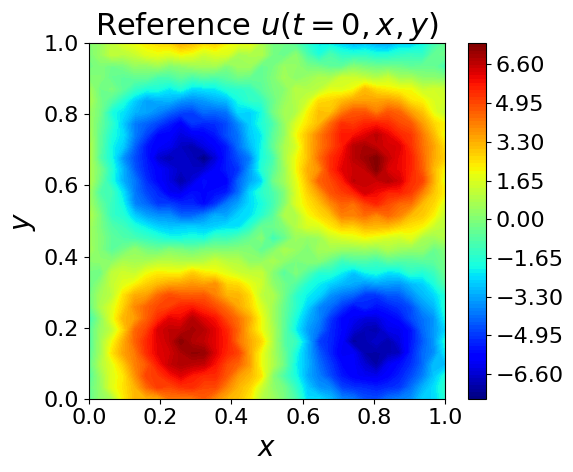

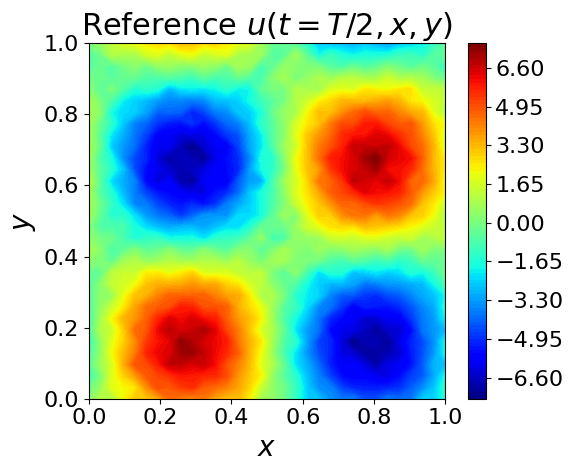

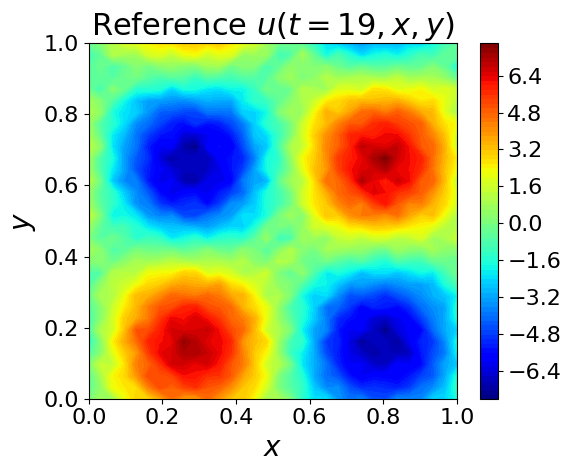

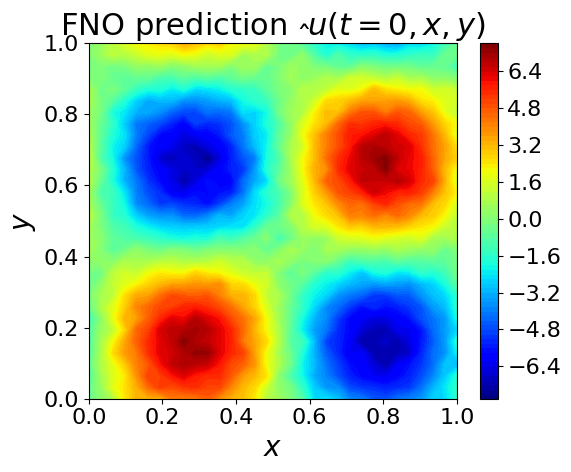

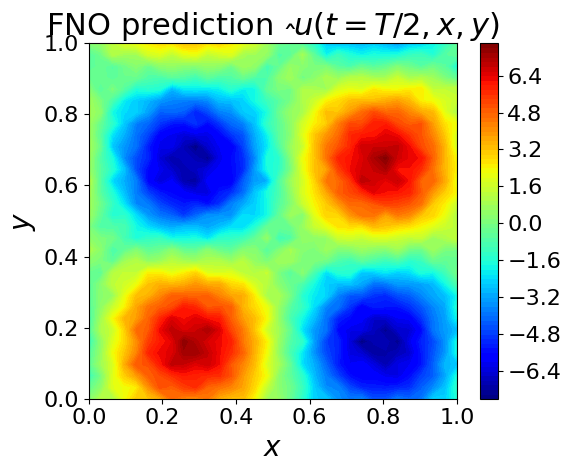

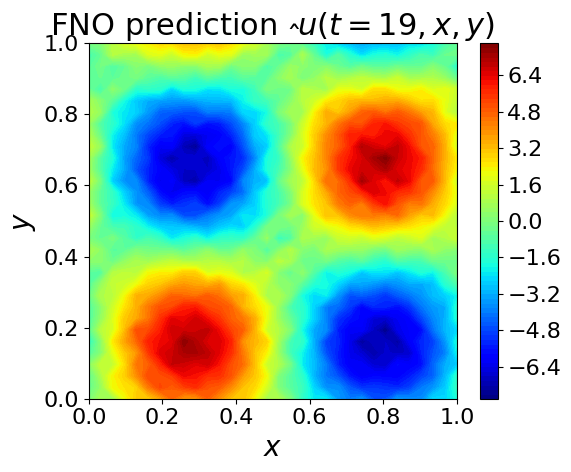

In [21]:
import pickle as pl
from matplotlib import cm   # если ещё не импортировали

# --- 1. получаем предсказание модели для одного тестового примера -----------
idx = 0                       # <- номер примера в тестовой выборке
with torch.no_grad():
    xx = test_a[idx:idx+1].to(device)         # (1, S, S, T_in+2)
    pred_list = []

    for t in range(0, T, step):
        im = model(xx)                        # (1, S, S, step)
        pred_list.append(im.squeeze(0).cpu()) # сохраняем без batch dim
        xx = torch.cat(
            (xx[..., step:-2], im,
             gridx[:1], gridy[:1]), dim=-1
        )

pred = torch.cat(pred_list, dim=-1)           # (S, S, T)

# --- 2. подготавливаем сетку для contourf ----------------------------------
x = gridx[0, :, 0, 0].cpu().numpy()           # (S,)
y = gridy[0, 0, :, 0].cpu().numpy()           # (S,)
X, Y = np.meshgrid(x, y, indexing="ij")

truth = test_u[idx].cpu().numpy()             # (S, S, T)
pred  = pred.numpy()

# --- 3. выбираем интересующие моменты времени -------------------------------
snapshots = {
    "t = 0"          : 0,
    "t = T/2"        : T // 2,
    f"t = {T*step-1}" : T - 1,
}

plt.rcParams.update({"font.size": 16})
for i, (title, t_idx) in enumerate(snapshots.items(), start=1):
    fig = plt.figure(i, figsize=(6, 5))
    ax  = fig.add_subplot()

    # --- контуры истинного решения -----------------------------------------
    cp = ax.contourf(X, Y,
                     truth[:, :, t_idx].T, 100,
                     cmap=cm.jet)
    fig.colorbar(cp)
    ax.set_xlabel(r"$x$", fontsize=20)
    ax.set_ylabel(r"$y$", fontsize=20)
    ax.set_title(f"Reference $u({title}, x, y)$", fontsize=22)
    plt.tight_layout()

    # --- при желании сохраняем фигуру в pickle -----------------------------
    with open(f"figs/ref_{t_idx:03d}.pickle", "wb") as f:
        pl.dump(fig, f)
        pl.dump(ax, f)
        pl.dump(cp, f)

# --- 4. аналогичные картинки для предсказания --------------------------------
for i, (title, t_idx) in enumerate(snapshots.items(), start=len(snapshots)+1):
    fig = plt.figure(i, figsize=(6, 5))
    ax  = fig.add_subplot()

    cpp = ax.contourf(X, Y,
                      pred[:, :, t_idx].T, 100,
                      cmap=cm.jet)
    fig.colorbar(cpp)
    ax.set_xlabel(r"$x$", fontsize=20)
    ax.set_ylabel(r"$y$", fontsize=20)
    ax.set_title(f"FNO prediction $\\hat u({title}, x, y)$", fontsize=22)
    plt.tight_layout()

    with open(f"figs/pred_{t_idx:03d}.pickle", "wb") as f:
        pl.dump(fig, f)
        pl.dump(ax, f)
        pl.dump(cpp, f)

plt.show()
plt.close("all")


In [8]:
import imageio

frames = []
for t_idx in range(T):
    err = np.abs(truth[:, :, t_idx] - pred[:, :, t_idx])
    fig, ax = plt.subplots()
    cp = ax.contourf(X, Y, err.T, 100, cmap=cm.inferno)
    ax.set_title(f"Error at t = {t_idx}")
    plt.tight_layout()
    buf = f"_tmp_{t_idx:03d}.png"
    fig.savefig(buf)
    frames.append(imageio.v2.imread(buf))
    plt.close(fig)
    os.remove(buf)

imageio.mimsave("error_evolution.gif", frames, fps=4)


Тестирование модели...
Средняя ошибка на тестовых данных: 0.058308
Создание визуализаций...


FileNotFoundError: [Errno 2] No such file or directory: 'image/ns_fourier_2d_rnn_V10000_T20_N200_ep1000_m12_w20_comparison.png'

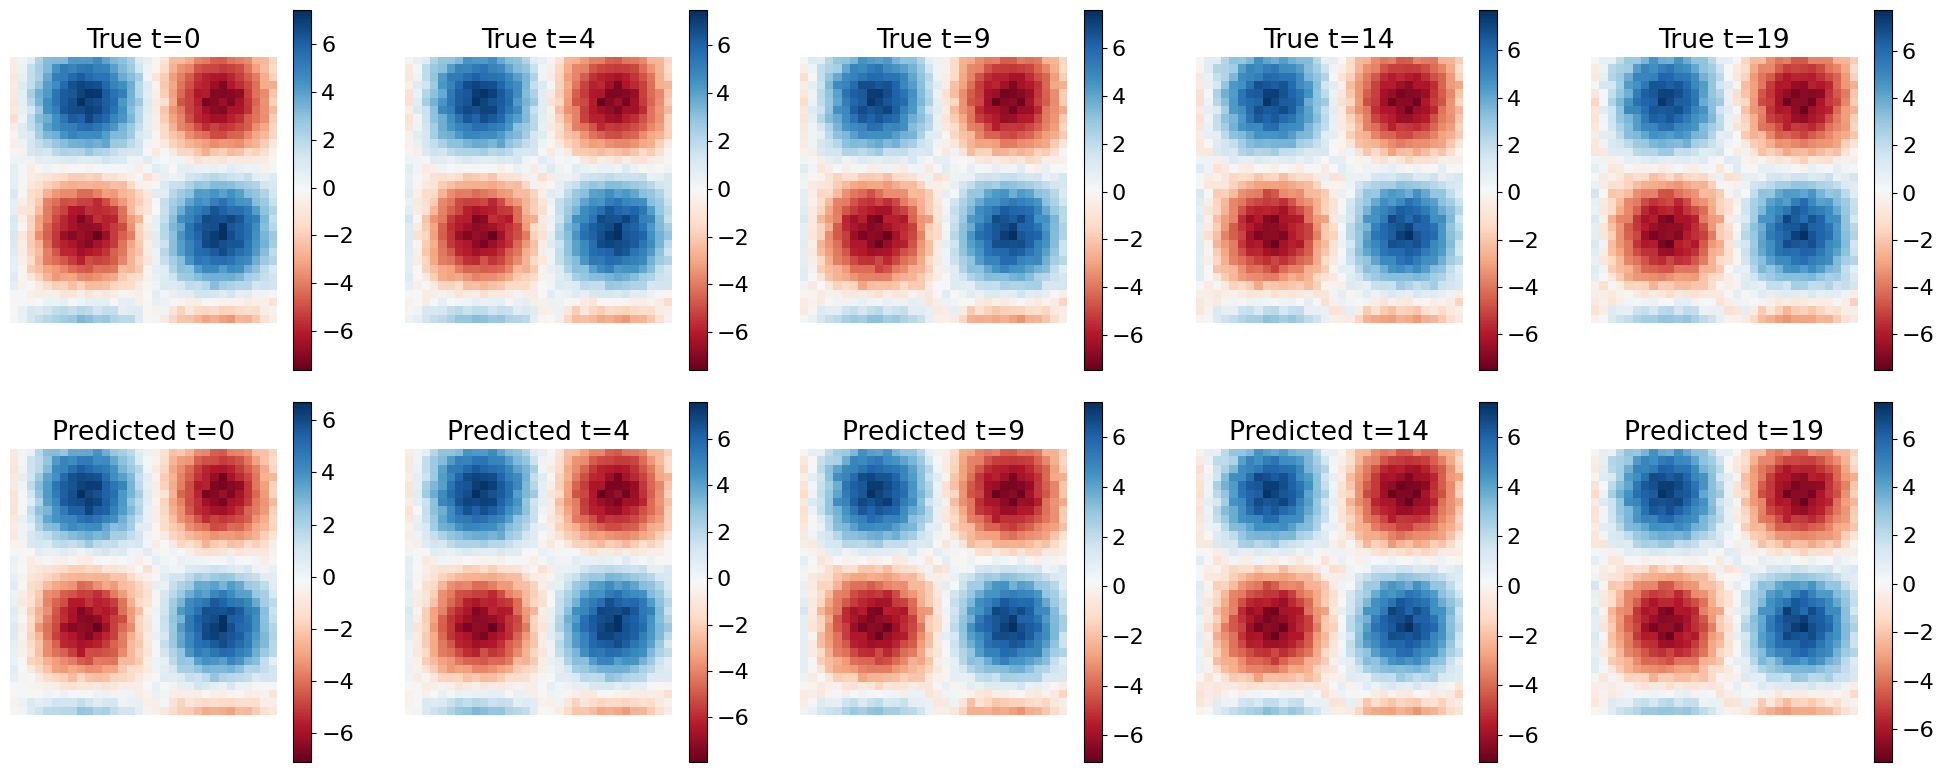

In [22]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from matplotlib.animation import FuncAnimation

# 1. ЗАГРУЗКА ОБУЧЕННОЙ МОДЕЛИ
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load(path_model, map_location=device)
model.eval()

# 2. ФУНКЦИЯ ДЛЯ АВТООРЕГРЕССИВНОГО ПРОГНОЗА
def predict_sequence(model, initial_conditions, n_steps, device):
    """
    Делает долгосрочный прогноз автоорегрессивно
    
    Args:
        model: обученная модель
        initial_conditions: начальные условия [1, H, W, T_in+2] (с координатами)
        n_steps: количество шагов для предсказания
        device: устройство
    
    Returns:
        predictions: предсказанная последовательность [1, H, W, n_steps]
    """
    model.eval()
    predictions = []
    
    # Подготавливаем координаты
    S = initial_conditions.shape[1]
    gridx = torch.tensor(np.linspace(0, 1, S), dtype=torch.float)
    gridx = gridx.reshape(1, S, 1, 1).repeat([1, 1, S, 1])
    gridy = torch.tensor(np.linspace(0, 1, S), dtype=torch.float)
    gridy = gridy.reshape(1, 1, S, 1).repeat([1, S, 1, 1])
    gridx, gridy = gridx.to(device), gridy.to(device)
    
    # Текущий вход
    current_input = initial_conditions.to(device)
    
    with torch.no_grad():
        for step in range(n_steps):
            # Предсказываем следующий кадр
            pred = model(current_input)
            predictions.append(pred.cpu().numpy())
            
            # Обновляем вход для следующего шага
            # Убираем самый старый кадр, добавляем предсказанный
            current_input = torch.cat([
                current_input[..., 1:-2],  # Убираем старый кадр и координаты
                pred,                       # Добавляем предсказание
                gridx,                      # Добавляем координаты обратно
                gridy
            ], dim=-1)
            
            if step % 10 == 0:
                print(f"Шаг {step}/{n_steps} завершен")
    
    return np.concatenate(predictions, axis=-1)

# 3. ТЕСТИРОВАНИЕ НА ТЕСТОВЫХ ДАННЫХ
def test_model(model, test_loader, device):
    """Тестирует модель на тестовых данных"""
    model.eval()
    test_loss = 0
    myloss = LpLoss(size_average=False)
    
    # Подготавливаем координаты
    S = 32
    gridx = torch.tensor(np.linspace(0, 1, S), dtype=torch.float)
    gridx = gridx.reshape(1, S, 1, 1).repeat([1, 1, S, 1])
    gridy = torch.tensor(np.linspace(0, 1, S), dtype=torch.float)
    gridy = gridy.reshape(1, 1, S, 1).repeat([1, S, 1, 1])
    gridx, gridy = gridx.to(device), gridy.to(device)
    
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for xx, yy in test_loader:
            xx, yy = xx.to(device), yy.to(device)
            batch_size = xx.shape[0]
            
            # Автоорегрессивное предсказание
            pred_sequence = []
            for t in range(0, yy.shape[-1], 1):  # T шагов
                pred = model(xx)
                pred_sequence.append(pred)
                
                # Обновляем вход
                xx = torch.cat([
                    xx[..., 1:-2],
                    pred,
                    gridx.repeat([batch_size, 1, 1, 1]),
                    gridy.repeat([batch_size, 1, 1, 1])
                ], dim=-1)
            
            # Собираем предсказания
            pred_full = torch.cat(pred_sequence, dim=-1)
            
            # Вычисляем ошибку
            loss = myloss(pred_full.reshape(batch_size, -1), yy.reshape(batch_size, -1))
            test_loss += loss.item()
            
            all_predictions.append(pred_full.cpu().numpy())
            all_targets.append(yy.cpu().numpy())
    
    avg_loss = test_loss / len(test_loader.dataset)
    print(f"Средняя ошибка на тестовых данных: {avg_loss:.6f}")
    
    return np.concatenate(all_predictions), np.concatenate(all_targets)

# 4. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
def visualize_prediction(true_sequence, pred_sequence, sample_idx=0, save_path=None):
    """Визуализирует сравнение истинной и предсказанной последовательностей"""
    
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    
    # Выбираем временные точки для показа
    time_points = np.linspace(0, true_sequence.shape[-1]-1, 5).astype(int)
    
    for i, t in enumerate(time_points):
        # Истинные данные
        im1 = axes[0, i].imshow(true_sequence[sample_idx, :, :, t], cmap='RdBu')
        axes[0, i].set_title(f'True t={t}')
        axes[0, i].axis('off')
        plt.colorbar(im1, ax=axes[0, i])
        
        # Предсказанные данные
        im2 = axes[1, i].imshow(pred_sequence[sample_idx, :, :, t], cmap='RdBu')
        axes[1, i].set_title(f'Predicted t={t}')
        axes[1, i].axis('off')
        plt.colorbar(im2, ax=axes[1, i])
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

def create_animation(sequence, title, save_path=None):
    """Создает анимацию последовательности"""
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Находим общий диапазон значений
    vmin, vmax = sequence.min(), sequence.max()
    
    im = ax.imshow(sequence[0, :, :, 0], cmap='RdBu', vmin=vmin, vmax=vmax)
    ax.set_title(f'{title} - t=0')
    ax.axis('off')
    plt.colorbar(im)
    
    def animate(frame):
        im.set_array(sequence[0, :, :, frame])
        ax.set_title(f'{title} - t={frame}')
        return [im]
    
    anim = FuncAnimation(fig, animate, frames=sequence.shape[-1], 
                        interval=100, blit=True, repeat=True)
    
    if save_path:
        anim.save(save_path, writer='pillow', fps=10)
    
    plt.show()
    return anim

# 5. ОСНОВНОЙ КОД ДЛЯ ТЕСТИРОВАНИЯ
if __name__ == "__main__":
    # Тестирование на тестовых данных
    print("Тестирование модели...")
    predictions, targets = test_model(model, test_loader, device)
    
    # Сохранение результатов
    scipy.io.savemat(f'pred/{path}_predictions.mat', {
        'predictions': predictions,
        'targets': targets
    })
    
    # Визуализация
    print("Создание визуализаций...")
    visualize_prediction(targets, predictions, sample_idx=0, 
                        save_path=f'image/{path}_comparison.png')
    
    # Создание анимации
    print("Создание анимаций...")
    create_animation(targets, "True Sequence", 
                    save_path=f'image/{path}_true_animation.gif')
    create_animation(predictions, "Predicted Sequence", 
                    save_path=f'image/{path}_pred_animation.gif')
    
    # Долгосрочный прогноз на новых данных
    print("Долгосрочный прогноз...")
    
    # Берем начальные условия из тестовых данных
    test_sample = test_a[0:1]  # Первый тестовый пример
    
    # Делаем прогноз на 200 шагов
    long_prediction = predict_sequence(model, test_sample, n_steps=200, device=device)
    
    # Сохраняем долгосрочный прогноз
    scipy.io.savemat(f'pred/{path}_long_prediction.mat', {
        'long_prediction': long_prediction,
        'initial_conditions': test_sample.numpy()
    })
    
    print("Анализ завершен!")